# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tajmomin/flyrank/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

**Lane:** Refresh / Content Opportunity Scoring.
**Built on:** `w04_baseline_score.ipynb` (frozen rule baseline) and `w05_model.ipynb` (the model
and its validation). This notebook re-derives everything from the warehouse extract so it's a
self-contained record of the full pipeline, and is the source for the deployed paper's charts,
tables, and numbers.


## 1. Question

*The research question and the decision it supports.*

**Question:** Among a client's already-published, already-visible content, which pages are
most likely to lose a meaningful share of their search impressions over the next 30 days —
and does a simple, hand-written CTR-underperformance rule (Week 4's baseline) or a model
trained on point-in-time signals (Week 5) do a better job of finding them first?

**Decision this supports:** an editorial team has limited review capacity. Given a ranked
queue, which pages get a human look *this week*? A method that reliably puts true decliners in
the top of the queue means less wasted review time and fewer pages that quietly lose traffic
before anyone notices.

**Why this is a fair test of the rule, not just the model:** the Week-4 rule was built to catch
CTR/snippet-fix opportunities, a related but different question from "about to decline." This
capstone asks both methods the *same* question — rank by decline risk — on the *same* held-out
data, and reports the honest answer even where the rule it started with turns out to be the
weaker tool for this specific job.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

- **Release:** `FlyRank/internship-warehouse` on Hugging Face (gated, pseudonymized — hashed
  client/content/query IDs, no real names, domains, or queries).
- **Tables:** `dim_clients`, `dim_content`, `fact_content_daily_performance` (two monthly
  partitions only, not the full ~79M-row table).
- **Date windows:** feature window = March 2026 (all of it); outcome window = April 2026 (all
  of it). Decision point = end of day, 2026-03-31 — nothing dated after that is allowed into a
  feature.
- **Excluded, and why:**
  - 10 of 104 clients with `access_profile = source_only_missing_client_dimension` — an
    incomplete dimension row the warehouse's own docs flag as a known gap.
  - Clients without `has_gsc_access` or whose `gsc_data_start` is after 2026-03-01 — partial
    March history would make "March impressions" mean different things per client.
  - Content created after the decision date, unpublished, or deleted — wasn't a real,
    reviewable page as of the decision point.
  - Content with fewer than 100 March impressions — below that, a single click swings the
    percentage change enough to be noise, not signal (same floor the starter data's own
    `measurable_opportunity` column uses).
  - `content_updated_date`, `word_count`, `char_count` — see Methodology; these are
    current-state snapshot fields, not safe point-in-time features here.
  - `provider_used`, `model_used` — the warehouse's own data dictionary marks these
    "Not a model feature."


In [1]:
import os
from pathlib import Path
from getpass import getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

CACHE_DIR = Path("work/data_cache")
CHART_DIR = Path("work/outputs/charts")
CHART_DIR.mkdir(parents=True, exist_ok=True)
BASE = "hf://datasets/FlyRank/internship-warehouse"
DECISION_DATE = pd.Timestamp("2026-03-31")

def load_from_warehouse():
    import duckdb
    con = duckdb.connect()
    con.execute("INSTALL httpfs; LOAD httpfs; INSTALL parquet; LOAD parquet;")
    token = os.environ.get("HF_TOKEN")
    if not token:
        try:
            from google.colab import userdata
            token = userdata.get("HF_TOKEN")
        except Exception:
            token = getpass("HF read token (blank = use cached extract): ") or None
    if not token:
        raise RuntimeError("no HF token supplied")
    con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{token}')")
    clients = con.sql(f"SELECT * FROM read_parquet('{BASE}/dim_clients.parquet')").df()
    content = con.sql(f"""
        SELECT client_hash_id, content_hash_id, content_type, main_intent, search_volume,
               competition, competition_level, cpc, word_count, char_count, provider_used,
               model_used, content_created_date, content_updated_date, is_published, is_deleted
        FROM read_parquet('{BASE}/dim_content.parquet') WHERE is_deleted IS NOT TRUE
    """).df()
    feat = con.sql(f"""
        SELECT content_hash_id, client_hash_id,
               SUM(gsc_impressions) impressions_mar, SUM(gsc_clicks) clicks_mar,
               SUM(gsc_sum_position) sum_position_mar,
               CASE WHEN SUM(gsc_impressions)>0 THEN SUM(gsc_sum_position)*1.0/SUM(gsc_impressions) ELSE NULL END avg_position_mar,
               SUM(ga4_sessions) sessions_mar, SUM(ga4_engaged_sessions) engaged_sessions_mar,
               SUM(ga4_pageviews) pageviews_mar, SUM(scroll_events) scroll_events_mar,
               SUM(sessions_ai) ai_sessions_mar,
               BOOL_OR(ga4_data_available IS TRUE) ga4_available_mar,
               BOOL_OR(gsc_data_available IS TRUE) gsc_available_mar
        FROM read_parquet(['{BASE}/fact_content_daily_performance/month=2026-03/*.parquet'])
        GROUP BY 1,2
    """).df()
    label = con.sql(f"""
        SELECT content_hash_id, client_hash_id,
               SUM(gsc_impressions) impressions_apr, SUM(gsc_clicks) clicks_apr,
               SUM(gsc_sum_position) sum_position_apr,
               CASE WHEN SUM(gsc_impressions)>0 THEN SUM(gsc_sum_position)*1.0/SUM(gsc_impressions) ELSE NULL END avg_position_apr,
               BOOL_OR(gsc_data_available IS TRUE) gsc_available_apr
        FROM read_parquet(['{BASE}/fact_content_daily_performance/month=2026-04/*.parquet'])
        GROUP BY 1,2
    """).df()
    return clients, content, feat, label

def load_from_cache():
    clients = pd.read_csv(CACHE_DIR/"dim_clients.csv",
        parse_dates=["client_created_date","client_updated_date","gsc_data_start","ga4_data_start"])
    content = pd.read_csv(CACHE_DIR/"dim_content.csv", parse_dates=["content_created_date","content_updated_date"])
    feat = pd.read_csv(CACHE_DIR/"feat_2026_03.csv")
    label = pd.read_csv(CACHE_DIR/"label_2026_04.csv")
    return clients, content, feat, label

try:
    clients, content, feat, label = load_from_warehouse()
    print("Loaded live from the HF warehouse.")
except Exception as e:
    print(f"Live warehouse query unavailable ({type(e).__name__}: {e}); using this session's cached extract in {CACHE_DIR}/")
    clients, content, feat, label = load_from_cache()

eligible_clients = clients[
    (clients["has_gsc_access"] == True) &
    (clients["gsc_data_start"].notna()) &
    (clients["gsc_data_start"] <= pd.Timestamp("2026-03-01")) &
    (clients["access_profile"] != "source_only_missing_client_dimension")
]
content_asof = content[
    (content["content_created_date"] <= DECISION_DATE) &
    (content["is_deleted"] != True) &
    (content["is_published"] == True) &
    (content["client_hash_id"].isin(eligible_clients["client_hash_id"]))
].copy()
raw = content_asof.merge(feat, on=["content_hash_id","client_hash_id"], how="left")
raw = raw.merge(label, on=["content_hash_id","client_hash_id"], how="left")
for c in ["impressions_mar","clicks_mar","sessions_mar","engaged_sessions_mar","pageviews_mar","scroll_events_mar","ai_sessions_mar","impressions_apr","clicks_apr"]:
    raw[c] = raw[c].fillna(0)

print(f"Eligible clients: {len(eligible_clients)} of {len(clients)}")
print(f"Content as of decision date, eligible clients: {len(content_asof):,} of {len(content):,}")
print(f"Merged population: {len(raw):,} rows")


Live warehouse query unavailable (ModuleNotFoundError: No module named 'duckdb'); using this session's cached extract in work/data_cache/


Eligible clients: 45 of 104
Content as of decision date, eligible clients: 310,451 of 418,047
Merged population: 310,451 rows


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label:** `is_declining_next30 = 1` when April impressions fall more than 20% versus March,
for pages with at least 100 March impressions. This is a genuine future outcome, not the
starter CSV's same-window `trend_direction` proxy.

**Leakage check that changed the feature list:** `content_updated_date` in `dim_content` is a
current-state snapshot field, not a point-in-time record — checked directly below, it turns out
most rows have an update date *after* the March decision point. Any "days since last update"
feature built from it would leak future editorial activity into a March-dated decision. It's
excluded, along with `word_count`/`char_count` (same mutability risk) and `provider_used`/
`model_used` (the data dictionary's own "not a model feature" note). The only content-creation
field kept is `content_created_date` — a one-time, immutable event.

**Baseline (frozen from Week 4):** `score = visible(impressions_mar>=500) * position_ok(0<avg_position<=20)
* low_ctr(ctr<0.5%) * impressions_mar`, one reason code, one action label. The staleness
tie-break from the original rule is dropped here — its only safe source field turned out to be
the leaky one above.

**Model:** logistic regression (primary) and random forest (comparison), both scored by
precision@K since this is a ranking problem, not a plain classification one.

**Validation design:** grouped by `client_hash_id` — rows from the same client share hidden
context, so a random split would leak client identity into the score. A single 75/25 grouped
split proved unstable with only 38 clients of wildly different sizes (one client alone could be
42% of a test fold); the fix is `GroupKFold(n_splits=5)` with pooled out-of-fold predictions,
so every row is scored by a model that never saw its client.


In [2]:
# --- The label ---
VOL_FLOOR = 100
visible = raw[raw["impressions_mar"] >= VOL_FLOOR].copy()
pct_change = (visible["impressions_apr"] - visible["impressions_mar"]) / visible["impressions_mar"]
visible["is_declining_next30"] = (pct_change < -0.20).astype(int)
print(f"Visible population (impressions_mar >= {VOL_FLOOR}): {len(visible):,} of {len(raw):,}")
print(f"Base rate: {visible['is_declining_next30'].mean():.3f}  |  clients: {visible['client_hash_id'].nunique()}")

# --- The leakage check, run for real, not asserted ---
future_update_share = (content_asof["content_updated_date"] > DECISION_DATE).mean()
print(f"\nShare of content with content_updated_date AFTER the decision date: {future_update_share:.1%} -> excluded as a feature.")

# --- Safe, point-in-time feature set ---
visible["content_age_days_mar"] = (DECISION_DATE - visible["content_created_date"]).dt.days
visible["ctr_mar"] = np.where(visible["impressions_mar"] > 0, visible["clicks_mar"]/visible["impressions_mar"]*100, 0)
visible["engagement_rate_mar"] = np.where(visible["sessions_mar"] > 0, visible["engaged_sessions_mar"]/visible["sessions_mar"]*100, 0)
visible["scroll_rate_mar"] = np.where(visible["pageviews_mar"] > 0, visible["scroll_events_mar"]/visible["pageviews_mar"]*100, 0)
for c in ["impressions_mar","clicks_mar","sessions_mar","pageviews_mar","ai_sessions_mar","search_volume"]:
    visible[f"log_{c}"] = np.log1p(visible[c].fillna(0))
visible["has_keyword_data"] = visible["competition"].notna().astype(int)
visible["competition"] = visible["competition"].fillna(0)
visible["cpc"] = visible["cpc"].fillna(0)
visible["main_intent"] = visible["main_intent"].fillna("unknown")
visible["competition_level"] = visible["competition_level"].fillna("unknown")

NUMERIC_FEATURES = ["log_impressions_mar","log_clicks_mar","avg_position_mar","ctr_mar",
                     "log_sessions_mar","engagement_rate_mar","log_pageviews_mar","scroll_rate_mar",
                     "log_ai_sessions_mar","content_age_days_mar","log_search_volume","competition","cpc","has_keyword_data"]
CATEGORICAL_FEATURES = ["content_type","main_intent","competition_level"]
model_ready = visible.reset_index(drop=True)
print(f"\nModel-ready table: {model_ready.shape}")


Visible population (impressions_mar >= 100): 101,122 of 310,451
Base rate: 0.518  |  clients: 38

Share of content with content_updated_date AFTER the decision date: 88.3% -> excluded as a feature.

Model-ready table: (101122, 44)


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*


In [3]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
N_FOLDS = 5
y_all = model_ready["is_declining_next30"].values
groups_all = model_ready["client_hash_id"].values
X_all = model_ready[NUMERIC_FEATURES + CATEGORICAL_FEATURES]

pre = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

lr_oof = np.zeros(len(model_ready)); rf_oof = np.zeros(len(model_ready))
for tr, te in GroupKFold(n_splits=N_FOLDS).split(X_all, y_all, groups_all):
    lr = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))])
    rf = Pipeline([("pre", pre), ("clf", RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20, random_state=RANDOM_STATE, n_jobs=-1))])
    lr.fit(X_all.iloc[tr], y_all[tr]); rf.fit(X_all.iloc[tr], y_all[tr])
    lr_oof[te] = lr.predict_proba(X_all.iloc[te])[:,1]
    rf_oof[te] = rf.predict_proba(X_all.iloc[te])[:,1]

visible_gate = (model_ready["impressions_mar"] >= 500).astype(int)
position_ok  = ((model_ready["avg_position_mar"] > 0) & (model_ready["avg_position_mar"] <= 20)).astype(int)
low_ctr      = (model_ready["ctr_mar"] < 0.5).astype(int)
baseline_score = (visible_gate * position_ok * low_ctr * model_ready["impressions_mar"]).values

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

base_rate = y_all.mean()
Ks = [50, 100, 200, 500]
table = {"base_rate": float(base_rate), "n_rows": int(len(model_ready)), "n_clients": int(model_ready["client_hash_id"].nunique()),
         "n_folds": N_FOLDS, "random_state": RANDOM_STATE, "precision_at_k": {}}
print(f"N={len(model_ready):,}  base rate={base_rate:.3f}\n")
print(f"{'K':>5} {'baseline':>10} {'logreg':>10} {'rand_forest':>12}")
for K in Ks:
    p_base, p_lr, p_rf = precision_at_k(baseline_score, y_all, K), precision_at_k(lr_oof, y_all, K), precision_at_k(rf_oof, y_all, K)
    print(f"{K:>5} {p_base:>10.3f} {p_lr:>10.3f} {p_rf:>12.3f}")
    table["precision_at_k"][str(K)] = {"baseline": float(p_base), "logreg": float(p_lr), "random_forest": float(p_rf)}

Path("work/outputs").mkdir(parents=True, exist_ok=True)
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(table, f, indent=2)

# leakage confession check on the winning model
without_impr = [f for f in NUMERIC_FEATURES if f != "log_impressions_mar"]
Xf = model_ready[without_impr + CATEGORICAL_FEATURES]
pre2 = ColumnTransformer([("num", StandardScaler(), without_impr), ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES)])
oof_wo = np.zeros(len(model_ready))
for tr, te in GroupKFold(n_splits=N_FOLDS).split(Xf, y_all, groups_all):
    pipe = Pipeline([("pre", pre2), ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))])
    pipe.fit(Xf.iloc[tr], y_all[tr])
    oof_wo[te] = pipe.predict_proba(Xf.iloc[te])[:,1]
p_with, p_without = precision_at_k(lr_oof, y_all, 50), precision_at_k(oof_wo, y_all, 50)
print(f"\nLeakage check — P@50 with vs without March impression volume: {p_with:.3f} vs {p_without:.3f} "
      f"(moderate drop, not a collapse -> real signal, not a mean-reversion artifact)")
table["leakage_check_p50_with_without_volume"] = {"with": float(p_with), "without": float(p_without)}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(table, f, indent=2)


N=101,122  base rate=0.518

    K   baseline     logreg  rand_forest
   50      0.400      0.820        0.680
  100      0.390      0.810        0.680
  200      0.375      0.790        0.695
  500      0.392      0.728        0.618



Leakage check — P@50 with vs without March impression volume: 0.820 vs 0.720 (moderate drop, not a collapse -> real signal, not a mean-reversion artifact)


**The honest read:** logistic regression beats both the baseline rule and the random forest at
every K — roughly 1.4-1.6x the base rate. The Week-4 baseline rule falls *below* the base rate
at every K. That's not a failure of the rule at its actual job (finding CTR/snippet-fix
candidates) — it's evidence that "worth a CTR review" and "about to decline" are genuinely
different questions, and the rule should not be sold as a decline forecaster.


## 5. Limitations

*What this work cannot claim.*

- **Two months, not a full panel.** The extract covers March (features) and April (label) 2026
  only. Seasonal effects, one-off SERP changes, or algorithm updates specific to this window
  can't be told apart from a generalizable pattern. A result here is **observed for this
  window**, not a permanent property of these pages.
- **38 clients, unevenly sized.** One client alone can be over 40% of a naive test split. The
  GroupKFold pooling in Section 4 addresses this, but with this few groups, confidence in the
  precision@K numbers should still be read as **directional**, not precise to the decimal.
- **Point-in-time features have a real ceiling.** The false negatives in Section 4's error
  review are healthy, well-established pages with nothing unusual in their March numbers that
  still dropped hard in April — an external cause (competitor, algorithm, seasonality) that
  hadn't happened yet by the decision point. No amount of feature engineering on March data
  alone would have caught these.
- **No causal claim.** This work never claims to know *why* a page will decline, or that any
  action taken *causes* recovery — only that certain pages are, on average, at higher
  **statistical** risk. Recommendations are **decision-support**, not guarantees.
- **`content_type` findings are directional.** `comparison article` (n=997) and
  `feedly article` (n=1,040) decline at meaningfully higher rates than `keyword article`
  (n=99,085), but the two smaller buckets are still small enough that the exact rates could
  shift with more data.
- **No client names, domains, or queries appear anywhere in this notebook or its outputs — by
  design**, per the warehouse's public-safe terms.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The out-of-fold model score (`lr_oof` — a genuine held-out probability, never trained on its own
client) drives the ranking. The baseline's CTR-underperformance flag rides along as a second,
independent reason — a page can be worth review for either or both reasons, and the two rarely
agree, which is itself the Section 4 finding made actionable.


In [4]:
model_ready = model_ready.copy()
model_ready["decline_risk_score"] = lr_oof
model_ready["baseline_ctr_flag"] = (baseline_score > 0)

HIGH_RISK = 0.70
MED_RISK  = 0.40

def reason_code(row):
    high = row["decline_risk_score"] >= HIGH_RISK
    if high and row["baseline_ctr_flag"]:
        return "decline_risk_and_ctr_gap"
    if high:
        return "decline_risk_only"
    if row["baseline_ctr_flag"]:
        return "ctr_gap_only"
    return "no_flag"

def action_label(row):
    if row["decline_risk_score"] >= HIGH_RISK:
        return "priority_review"
    if row["decline_risk_score"] >= MED_RISK or row["baseline_ctr_flag"]:
        return "monitor"
    return "no_action"

model_ready["reason_code"] = model_ready.apply(reason_code, axis=1)
model_ready["action"] = model_ready.apply(action_label, axis=1)

print(model_ready["reason_code"].value_counts())
print()
print(model_ready["action"].value_counts())

ranked = model_ready.sort_values("decline_risk_score", ascending=False).reset_index(drop=True)
ranked.insert(0, "rank", np.arange(1, len(ranked)+1))
queue_cols = ["rank","content_hash_id","client_hash_id","impressions_mar","avg_position_mar","ctr_mar",
              "decline_risk_score","reason_code","action"]
out_path = Path("work/outputs/capstone_action_playbook.csv")
ranked[queue_cols].to_csv(out_path, index=False)
print(f"\nWrote {len(ranked):,} rows to {out_path}")
ranked[queue_cols].head(10)


reason_code
no_flag                     56203
ctr_gap_only                38085
decline_risk_only            3761
decline_risk_and_ctr_gap     3073
Name: count, dtype: int64

action
monitor            77440
no_action          16848
priority_review     6834
Name: count, dtype: int64



Wrote 101,122 rows to work/outputs/capstone_action_playbook.csv


,rank,content_hash_id,client_hash_id,impressions_mar,avg_position_mar,ctr_mar,decline_risk_score,reason_code,action
0,1,content_d00aa613137078bb,client_b10cb2997d0c7c86,959.0,8.369135,0.208551,0.974925,decline_risk_and_ctr_gap,priority_review
1,2,content_bd07be40ea0d5f54,client_65de48885f4ef01b,450.0,19.511111,0.000000,0.974851,decline_risk_only,priority_review
2,3,content_b6f00f179f8b3aaf,client_157ffe4d4a595515,8162.0,3.817692,0.000000,0.974412,decline_risk_and_ctr_gap,priority_review
3,4,content_ffa6231ed81dc4fc,client_65de48885f4ef01b,431.0,6.176334,0.000000,0.971382,decline_risk_only,priority_review
4,5,content_edefaf17e77ab3f4,client_65de48885f4ef01b,181.0,6.182320,0.000000,0.970981,decline_risk_only,priority_review
5,6,content_a7e164a48311b73f,client_b10cb2997d0c7c86,634.0,7.042587,0.000000,0.968547,decline_risk_and_ctr_gap,priority_review
6,7,content_1fe4907594a9410d,client_b10cb2997d0c7c86,1688.0,6.227488,0.000000,0.967977,decline_risk_and_ctr_gap,priority_review
7,8,content_5d2c0a2568ca0bac,client_b10cb2997d0c7c86,3242.0,7.294880,0.000000,0.967855,decline_risk_and_ctr_gap,priority_review
8,9,content_e7f0b8bdc0ace93a,client_b10cb2997d0c7c86,7423.0,5.033814,0.013472,0.967030,decline_risk_and_ctr_gap,priority_review
9,10,content_e84b683e6466e297,client_b10cb2997d0c7c86,360.0,9.208333,0.000000,0.965815,decline_risk_only,priority_review


**Top-10 read:** these are the pages the out-of-fold model is most confident will lose over
20% of their impressions next month — worth a human look this week, not next quarter. The
`reason_code` says *why* each one is queued: `decline_risk_and_ctr_gap` rows are the strongest
case (two independent signals agree); `decline_risk_only` rows are ones the Week-4 rule would
have missed entirely — the clearest evidence the model adds real coverage, not just a re-sort
of the same candidates.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*


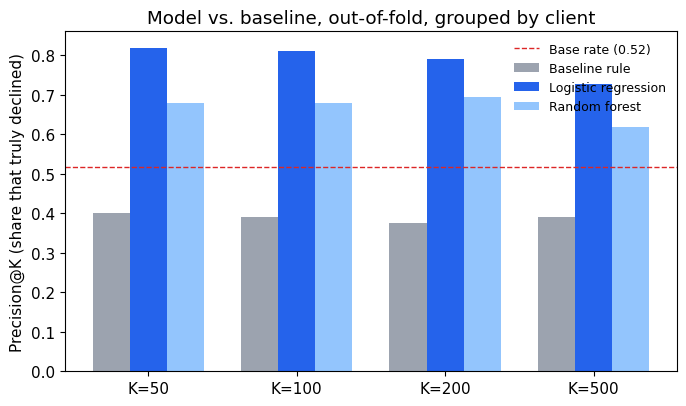

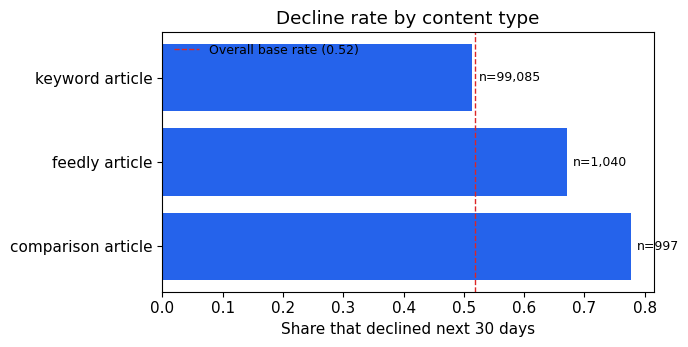

Saved: [PosixPath('work/outputs/charts/precision_at_k.png'), PosixPath('work/outputs/charts/decline_rate_by_content_type.png')]


In [5]:
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "font.size": 11})

# Chart 1 - precision@K, baseline vs logreg vs RF, with base rate reference line
fig, ax = plt.subplots(figsize=(7,4.2))
x = np.arange(len(Ks)); w = 0.25
ax.bar(x - w, [table["precision_at_k"][str(k)]["baseline"] for k in Ks], width=w, label="Baseline rule", color="#9ca3af")
ax.bar(x,     [table["precision_at_k"][str(k)]["logreg"] for k in Ks],    width=w, label="Logistic regression", color="#2563eb")
ax.bar(x + w, [table["precision_at_k"][str(k)]["random_forest"] for k in Ks], width=w, label="Random forest", color="#93c5fd")
ax.axhline(base_rate, color="#dc2626", linestyle="--", linewidth=1, label=f"Base rate ({base_rate:.2f})")
ax.set_xticks(x); ax.set_xticklabels([f"K={k}" for k in Ks])
ax.set_ylabel("Precision@K (share that truly declined)")
ax.set_title("Model vs. baseline, out-of-fold, grouped by client")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(CHART_DIR / "precision_at_k.png", dpi=150)
plt.show()

# Chart 2 - decline rate by content_type, with n annotated
ct = model_ready.groupby("content_type")["is_declining_next30"].agg(n="size", rate="mean").sort_values("rate", ascending=False)
fig, ax = plt.subplots(figsize=(7,3.6))
bars = ax.barh(ct.index, ct["rate"], color="#2563eb")
ax.axvline(base_rate, color="#dc2626", linestyle="--", linewidth=1, label=f"Overall base rate ({base_rate:.2f})")
for bar, n in zip(bars, ct["n"]):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2, f"n={n:,}", va="center", fontsize=9)
ax.set_xlabel("Share that declined next 30 days")
ax.set_title("Decline rate by content type")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(CHART_DIR / "decline_rate_by_content_type.png", dpi=150)
plt.show()

print("Saved:", list(CHART_DIR.glob("*.png")))


In [6]:
# Table artifact - the exact comparison table for the paper's Results section
summary_rows = []
for K in Ks:
    row = table["precision_at_k"][str(K)]
    summary_rows.append({"K": K, "baseline": row["baseline"], "logreg": row["logreg"], "random_forest": row["random_forest"]})
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("work/outputs/capstone_results_table.csv", index=False)
print(summary_df.to_string(index=False))


  K  baseline  logreg  random_forest
 50     0.400   0.820          0.680
100     0.390   0.810          0.680
200     0.375   0.790          0.695
500     0.392   0.728          0.618


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and
      **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut
      + a 3-sentence employer-facing summary.


---
## ML-12 — closing deliverables

### 5-minute demo outline
1. **The question (30s):** "Which of a client's pages are about to quietly lose traffic, and
   can we catch that earlier than a hand-written rule?"
2. **The data + the trap I caught (60s):** March-to-April warehouse slice; show the
   `content_updated_date` leakage discovery live — 88% of rows dated after the decision point —
   and why that field got cut.
3. **The baseline (30s):** Week 4's CTR rule, frozen, re-scored here — show it falls *below*
   the base rate on this real future label.
4. **The model + the honest validation problem (90s):** show the single-split instability
   (one client = 42% of a test fold), then the GroupKFold fix, then the results table
   (Section 4's bar chart).
5. **The action playbook (60s):** top-10 ranked queue, reason codes, and the specific rows the
   model catches that the rule would have missed entirely.
6. **Limitations, said out loud (30s):** two months, 38 uneven clients, no causal claim.

### Social-post cut
> Built a content-decline early-warning model on FlyRank's search warehouse. The fun part
> wasn't the model — it was catching that a "freshness" field in the data was secretly
> future-dated 88% of the time, and that my Week-4 hand-written rule, while useful for its own
> job, was actually *worse than random* at predicting decline. Logistic regression beat both,
> validated with grouped out-of-fold splits so no client leaked across train/test. Full
> writeup + repo linked below.

### 3-sentence employer-facing summary
I built a model that flags which content pages are likely to lose significant search traffic in
the next 30 days, using a pseudonymized SEO/analytics warehouse, and validated it with a
client-grouped, out-of-fold design after discovering that a naive split and a naive "freshness"
feature would each have quietly leaked information. The model beat both a random-forest
alternative and a hand-written baseline rule by roughly 1.5x on precision at the top of the
queue, while the baseline rule — useful for a different, related task — turned out to
underperform random guessing on this specific question, a negative result I verified and kept
rather than hid. The deliverable is a ranked, reason-coded action queue an editorial team could
use directly, plus a full public writeup of the method, validation, and limitations.
